Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0026 - val_loss: 0.0388
Epoch 2/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 5.2103e-05 - val_loss: 0.0316
Epoch 3/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 3.8018e-05 - val_loss: 0.0230
Epoch 4/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 3.0087e-05 - val_loss: 0.0180
Epoch 5/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 2.6897e-05 - val_loss: 0.0130
Epoch 6/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 2.5030e-05 - val_loss: 0.0105
Epoch 7/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.9097e-05 - val_loss: 0.0068
Epoch 8/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.6888e-05 - val_loss: 0.0067
Epoch 9/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.7098e-05 - val_loss: 0.0047
Epoch 10/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.4107e-05 - val_loss: 0.0040
Epoch 11/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 1.3455e-05 - val_loss: 0.0044
Epoch 12/20
269/269 

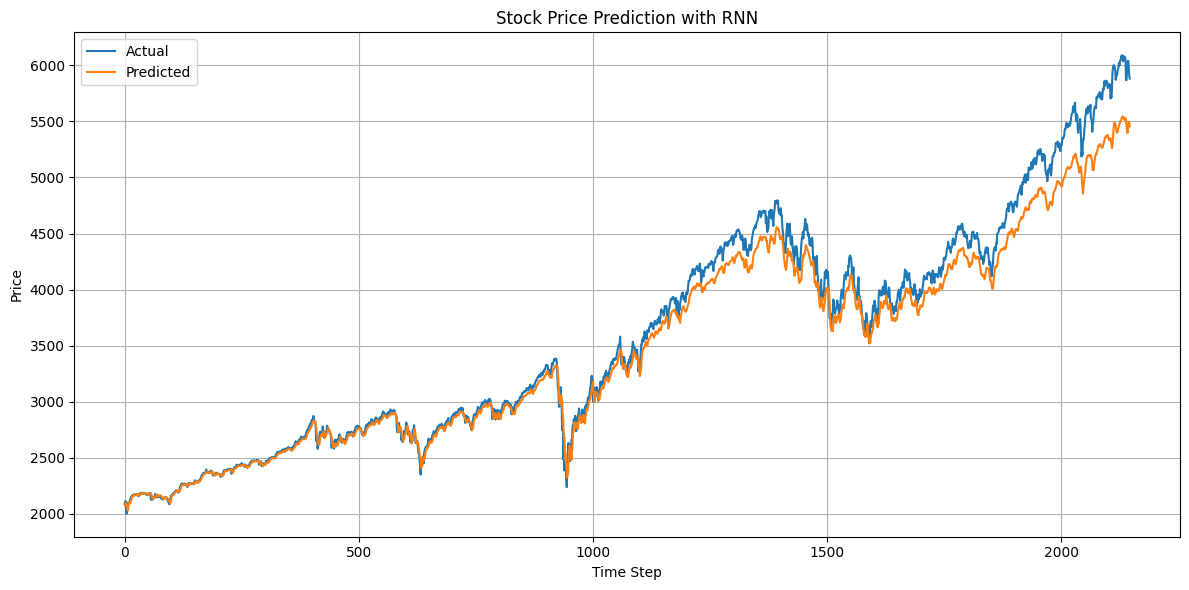

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Load your data
df = pd.read_csv("sp500_historical_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Step 1: Extract 'Close' prices and scale
close_prices = df[['Close']].values
scaler = MinMaxScaler()
scaled_close = scaler.fit_transform(close_prices)

# Step 2: Create sequences
def create_sequences(data, window_size=30):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window_size = 30
X, y = create_sequences(scaled_close, window_size)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Step 3: Split into train and test
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Step 4: Build RNN model
model = Sequential()
model.add(SimpleRNN(50, activation='tanh', input_shape=(window_size, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Step 5: Predict
y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
mae = mean_absolute_error(y_test_orig, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

# Step 6: Plot
plt.figure(figsize=(12,6))
plt.plot(y_test_orig, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.title('Stock Price Prediction with RNN')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

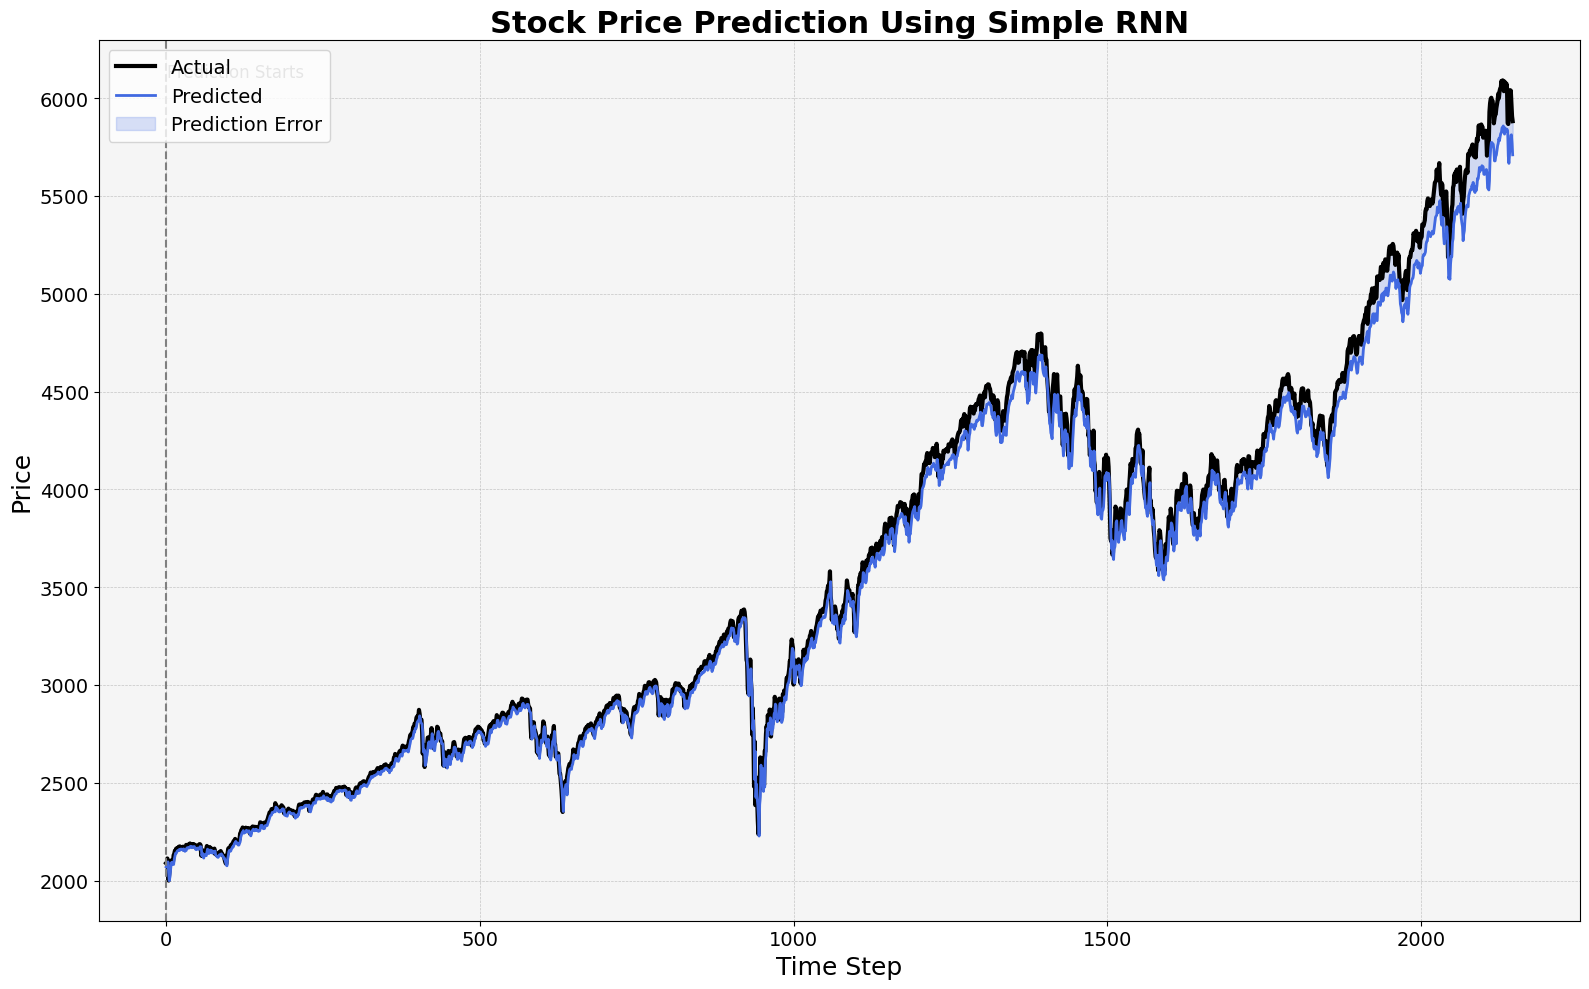

In [ ]:
# Step 6: Final polished plot with shading and annotation
plt.figure(figsize=(16,10))

# Plot Actual and Predicted
plt.plot(y_test_orig, label='Actual', linewidth=3, color='black')
plt.plot(y_pred, label='Predicted', linewidth=2, color='royalblue')

# Light shading for prediction error
plt.fill_between(
    np.arange(len(y_test_orig)),
    y_test_orig.flatten(),
    y_pred.flatten(),
    color='royalblue',
    alpha=0.2,
    label='Prediction Error'
)

# Annotate where predictions start (optional, if needed)
# Assuming prediction starts immediately at beginning of y_pred
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1.5)
plt.text(1, plt.ylim()[1]*0.97, 'Prediction Starts', fontsize=12, color='gray')

# Titles and labels
plt.title('Stock Price Prediction Using Simple RNN', fontsize=22, fontweight='bold')
plt.xlabel('Time Step', fontsize=18)
plt.ylabel('Price', fontsize=18)

# Legend
plt.legend(fontsize=14, loc='upper left')

# Grid
plt.grid(which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Improve ticks
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Background color
plt.gca().set_facecolor('#f5f5f5')
plt.gcf().set_facecolor('white')

# Tight layout
plt.tight_layout()

plt.show()


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


212/212 - 4s - 19ms/step - loss: 5.7989e-04 - val_loss: 3.2326e-05
Epoch 2/20
212/212 - 1s - 6ms/step - loss: 1.7079e-05 - val_loss: 2.9122e-05
Epoch 3/20
212/212 - 1s - 5ms/step - loss: 1.6149e-05 - val_loss: 2.7930e-05
Epoch 4/20
212/212 - 1s - 4ms/step - loss: 1.4771e-05 - val_loss: 2.7059e-05
Epoch 5/20
212/212 - 1s - 4ms/step - loss: 1.5196e-05 - val_loss: 2.7173e-05
Epoch 6/20
212/212 - 1s - 4ms/step - loss: 1.4512e-05 - val_loss: 2.9591e-05
Epoch 7/20
212/212 - 1s - 6ms/step - loss: 1.3071e-05 - val_loss: 2.1671e-05
Epoch 8/20
212/212 - 1s - 4ms/step - loss: 1.2588e-05 - val_loss: 2.5260e-05
Epoch 9/20
212/212 - 1s - 6ms/step - loss: 1.3222e-05 - val_loss: 2.0166e-05
Epoch 10/20
212/212 - 1s - 6ms/step - loss: 1.2788e-05 - val_loss: 2.4059e-05
Epoch 11/20
212/212 - 1s - 6ms/step - loss: 1.1504e-05 - val_loss: 2.0347e-05
Epoch 12/20
212/212 - 1s - 6ms/step - loss: 1.1410e-05 - val_loss: 1.9751e-05
Epoch 13/20
212/212 - 1s - 6ms/step - loss: 1.1309e-05 - val_loss: 2.1643e-05
Epoch

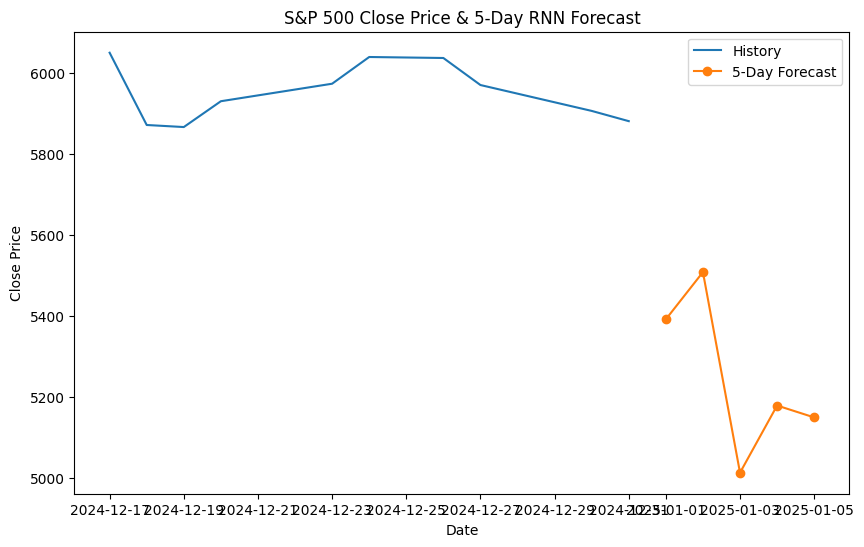

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# 1. Load & sort your data
df = pd.read_csv('sp500_historical_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
prices = df[['Close']].values

# 2. Scale to [0,1]
scaler = MinMaxScaler()
scaled = scaler.fit_transform(prices)

# 3. Build sequences: each X is 'lookback' days, each y is the next 'horizon' days
def create_sequences(data, lookback=60, horizon=5):
    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i : i + lookback, 0])
        y.append(data[i + lookback : i + lookback + horizon, 0])
    return np.array(X), np.array(y)

lookback = 15    # how many past days to use
horizon  = 10    # how many days ahead to predict

X, y = create_sequences(scaled, lookback, horizon)
# reshape for RNN: (samples, timesteps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

# 4. Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=False
)

# 5. Define a simple RNN that outputs 'horizon' values
model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(lookback, 1)),
    Dense(horizon)   # one unit per forecast day
])
model.compile(optimizer='adam', loss='mse')

# 6. Train
history = model.fit(
    X_train, y_train,
    epochs=20, batch_size=32,
    validation_split=0.1,
    verbose=2
)

# 7. Forecast the next 5 days
last_window = scaled[-lookback:].reshape((1, lookback, 1))
pred_scaled  = model.predict(last_window)[0]
pred_prices  = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

# 8. Plot history + forecast
plt.figure(figsize=(10, 6))
# last lookback days of real data
plt.plot(
    df['Date'].values[-lookback:],
    prices[-lookback:],
    label='History'
)
# future dates for the forecast
future_dates = pd.date_range(
    start=df['Date'].iloc[-1] + pd.Timedelta(days=1),
    periods=horizon
)
plt.plot(future_dates, pred_prices, marker='o', label='5-Day Forecast')
plt.title('S&P 500 Close Price & 5-Day RNN Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


302/302 - 6s - 19ms/step - loss: 8.9573e-04 - val_loss: 0.0165
Epoch 2/20
302/302 - 2s - 7ms/step - loss: 6.3086e-05 - val_loss: 0.0099
Epoch 3/20
302/302 - 3s - 8ms/step - loss: 5.0318e-05 - val_loss: 0.0079
Epoch 4/20
302/302 - 3s - 9ms/step - loss: 4.9112e-05 - val_loss: 0.0064
Epoch 5/20
302/302 - 3s - 10ms/step - loss: 4.6493e-05 - val_loss: 0.0035
Epoch 6/20
302/302 - 2s - 7ms/step - loss: 4.4009e-05 - val_loss: 0.0039
Epoch 7/20
302/302 - 3s - 9ms/step - loss: 4.3943e-05 - val_loss: 0.0022
Epoch 8/20
302/302 - 2s - 8ms/step - loss: 4.0245e-05 - val_loss: 0.0025
Epoch 9/20
302/302 - 2s - 8ms/step - loss: 3.8006e-05 - val_loss: 0.0014
Epoch 10/20
302/302 - 3s - 10ms/step - loss: 3.8974e-05 - val_loss: 0.0020
Epoch 11/20
302/302 - 2s - 7ms/step - loss: 3.4888e-05 - val_loss: 0.0019
Epoch 12/20
302/302 - 2s - 7ms/step - loss: 3.4893e-05 - val_loss: 0.0013
Epoch 13/20
302/302 - 2s - 7ms/step - loss: 3.5465e-05 - val_loss: 9.2666e-04
Epoch 14/20
302/302 - 3s - 9ms/step - loss: 3.3929e

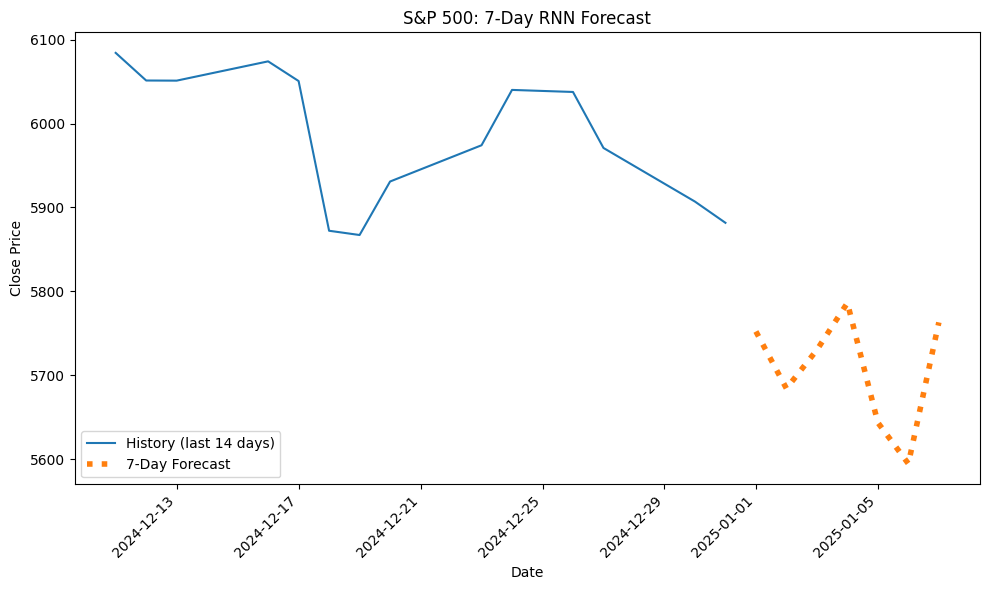

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# 1. Load & sort your data
df = pd.read_csv('sp500_historical_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
prices = df[['Close']].values

# 2. Scale to [0,1]
scaler = MinMaxScaler()
scaled = scaler.fit_transform(prices)

# 3. Build sequences for a 30-day lookback predicting the next 5 days
def create_sequences(data, lookback=30, horizon=5):
    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i : i + lookback, 0])
        y.append(data[i + lookback : i + lookback + horizon, 0])
    return np.array(X), np.array(y)

lookback = 30
horizon  = 7
X, y = create_sequences(scaled, lookback, horizon)
X = X.reshape((X.shape[0], lookback, 1))

# 4. Define & compile the RNN
model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(lookback, 1)),
    Dense(horizon)
])
model.compile(optimizer='adam', loss='mse')

# 5. Train on the entire dataset (with a small validation split internally)
history = model.fit(
    X, y,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=2
)

# 6. Forecast the next 5 days from the very end of your data
last_window = scaled[-lookback:].reshape((1, lookback, 1))
pred_scaled = model.predict(last_window)[0]
pred_prices = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

# 7. Plot only the last 15 days of history + your 5-day forecast, highlight prediction area, slanted labels, legend bottom-left
days_to_plot = 14
plt.figure(figsize=(10, 6))

# history slice
hist_dates = df['Date'].values[-days_to_plot:]
hist_prices = prices[-days_to_plot:]
plt.plot(hist_dates, hist_prices, label=f'History (last {days_to_plot} days)')

# future dates
future_dates = pd.date_range(
    start=df['Date'].iloc[-1] + pd.Timedelta(days=1),
    periods=horizon
)


# forecast as dotted line with thicker width and larger markers
plt.plot(future_dates, pred_prices,
        linestyle=':', linewidth=4,
         label=f'{horizon}-Day Forecast')

# rotate and align tick labels
plt.xticks(rotation=45, ha='right')

plt.title('S&P 500: 7-Day RNN Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()
